In [ ]:
# Prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For ignoring warning
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('/content/heart_disease_risk_dataset_earlymed.csv')
df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [ ]:
df.shape

(70000, 19)

In [ ]:
df['Heart_Risk'].value_counts()

,count
Heart_Risk,
0.0,35000
1.0,35000


In [ ]:
df.duplicated().sum()

np.int64(6245)

In [ ]:
df.isnull().sum()

,0
Chest_Pain,0
Shortness_of_Breath,0
Fatigue,0
Palpitations,0
Dizziness,0
Swelling,0
Pain_Arms_Jaw_Back,0
Cold_Sweats_Nausea,0
High_BP,0
High_Cholesterol,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

In [ ]:
from sklearn import preprocessing
for col in df.columns:
    if df[col].dtype == "float64":
        df[col] = df[col].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Chest_Pain           70000 non-null  int64
 1   Shortness_of_Breath  70000 non-null  int64
 2   Fatigue              70000 non-null  int64
 3   Palpitations         70000 non-null  int64
 4   Dizziness            70000 non-null  int64
 5   Swelling             70000 non-null  int64
 6   Pain_Arms_Jaw_Back   70000 non-null  int64
 7   Cold_Sweats_Nausea   70000 non-null  int64
 8   High_BP              70000 non-null  int64
 9   High_Cholesterol     70000 non-null  int64
 10  Diabetes             70000 non-null  int64
 11  Smoking              70000 non-null  int64
 12  Obesity              70000 non-null  int64
 13  Sedentary_Lifestyle  70000 non-null  int64
 14  Family_History       70000 non-null  int64
 15  Chronic_Stress       70000 non-null  int64
 16  Gender               7

In [ ]:
df

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,48,0
1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,46,0
2,1,0,0,1,0,0,0,0,1,1,0,1,1,1,0,0,1,66,0
3,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,60,1
4,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,69,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,30,0
69996,1,1,1,0,1,1,1,1,1,1,0,1,0,1,1,1,1,56,1
69997,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,53,0
69998,1,1,0,1,1,0,1,1,1,1,1,0,1,1,1,0,1,57,1


In [ ]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


In [ ]:
df

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,48,0
1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,46,0
2,1,0,0,1,0,0,0,0,1,1,0,1,1,1,0,0,1,66,0
3,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,60,1
4,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,69,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,30,0
69996,1,1,1,0,1,1,1,1,1,1,0,1,0,1,1,1,1,56,1
69997,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,53,0
69998,1,1,0,1,1,0,1,1,1,1,1,0,1,1,1,0,1,57,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Chest_Pain           70000 non-null  int64
 1   Shortness_of_Breath  70000 non-null  int64
 2   Fatigue              70000 non-null  int64
 3   Palpitations         70000 non-null  int64
 4   Dizziness            70000 non-null  int64
 5   Swelling             70000 non-null  int64
 6   Pain_Arms_Jaw_Back   70000 non-null  int64
 7   Cold_Sweats_Nausea   70000 non-null  int64
 8   High_BP              70000 non-null  int64
 9   High_Cholesterol     70000 non-null  int64
 10  Diabetes             70000 non-null  int64
 11  Smoking              70000 non-null  int64
 12  Obesity              70000 non-null  int64
 13  Sedentary_Lifestyle  70000 non-null  int64
 14  Family_History       70000 non-null  int64
 15  Chronic_Stress       70000 non-null  int64
 16  Gender               7

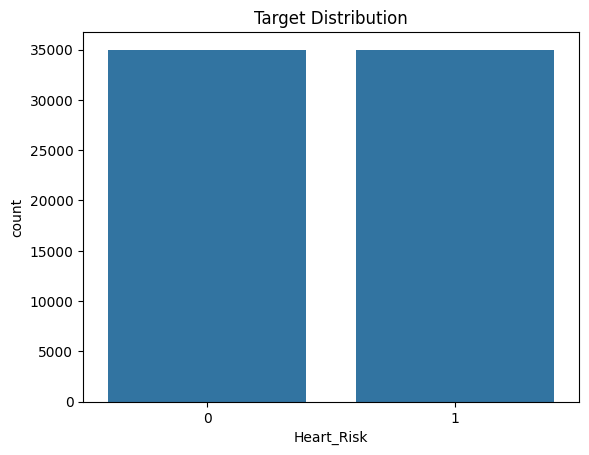

In [ ]:
#Let's check the distributaion of Target variable.
sns.countplot(x='Heart_Risk', data=df,)
plt.title('Target Distribution')
plt.savefig("Heart Riskr Target Distribution.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# function for plotting
def plot(col, df=df):
    return df.groupby(col)['Heart_Risk'].value_counts(normalize=True).unstack().plot(kind='bar', figsize=(8,5))

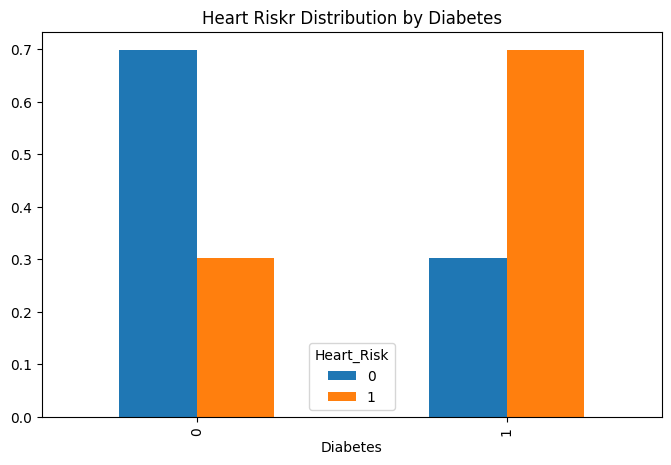

In [ ]:
plot('Diabetes')
plt.title('Heart Riskr Distribution by Diabetes')
plt.savefig("Heart Riskr Distribution by Diabete.pdf", dpi=300, bbox_inches='tight')
plt.show()

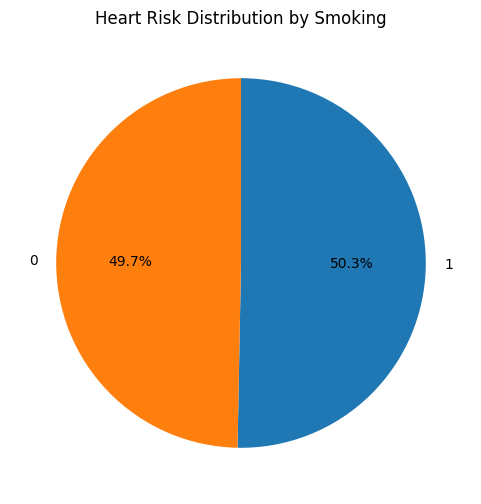

In [ ]:
import matplotlib.pyplot as plt

# Example: If your dataframe is df
smoking_counts = df['Smoking'].value_counts()

# Pie plot
plt.figure(figsize=(6,6))
plt.pie(
    smoking_counts,
    labels=smoking_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)

plt.title("Heart Risk Distribution by Smoking")
plt.savefig("Heart Risk Distribution by Smoking.pdf", dpi=300, bbox_inches='tight')
plt.show()


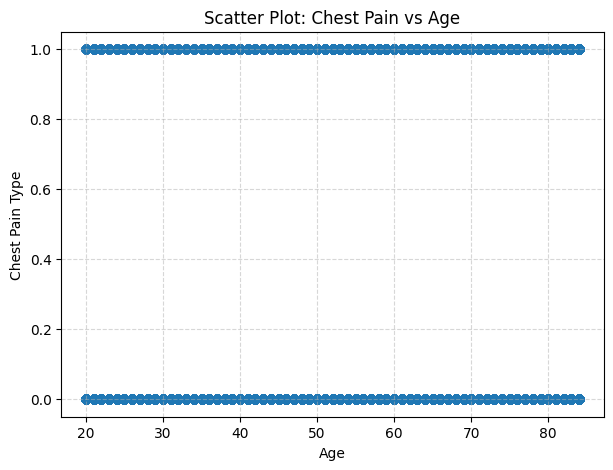

In [ ]:
import matplotlib.pyplot as plt

# Example scatter: Chest_Pain vs Age
plt.figure(figsize=(7,5))
plt.scatter(df['Age'], df['Chest_Pain'], alpha=0.6)

plt.xlabel("Age")
plt.ylabel("Chest Pain Type")
plt.title("Scatter Plot: Chest Pain vs Age")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig("Chest_Pain_Scatter.pdf", dpi=300, bbox_inches='tight')
plt.show()

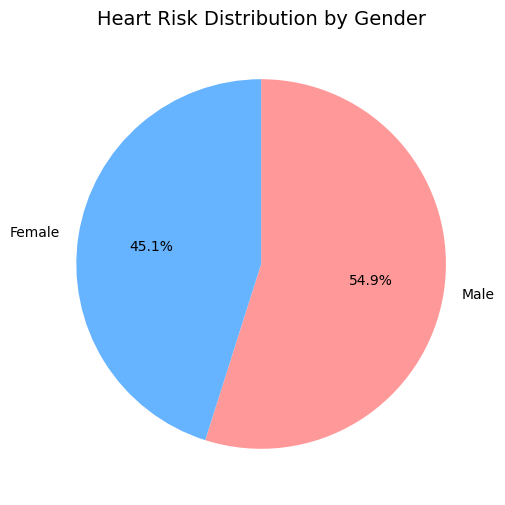

In [ ]:
import matplotlib.pyplot as plt

# Map 0 and 1 to labels
gender_labels = {0: "Female", 1: "Male"}
gender_counts = df['Gender'].map(gender_labels).value_counts()

# Pie plot for gender distribution
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=['#ff9999', '#66b3ff']  # pink for female, blue for male
)

plt.title("Heart Risk Distribution by Gender", fontsize=14)
plt.savefig("Heart_Risk_Distribution_by_Gender.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Finding Correlation
cn=df.corr()
cn

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
Chest_Pain,1.000000,0.358374,0.357769,0.355855,0.355235,0.354598,0.361464,0.363212,0.244110,0.238770,0.236488,0.237842,0.242998,0.240132,0.234853,0.245172,0.175881,0.366306,0.599944
Shortness_of_Breath,0.358374,1.000000,0.357634,0.357490,0.363827,0.355146,0.355827,0.356313,0.242838,0.242859,0.236285,0.239055,0.239488,0.241627,0.238551,0.245257,0.176676,0.363007,0.598772
Fatigue,0.357769,0.357634,1.000000,0.357452,0.355925,0.362082,0.365526,0.357106,0.241475,0.240997,0.237633,0.239051,0.237796,0.241742,0.235476,0.242715,0.171762,0.361132,0.599260
Palpitations,0.355855,0.357490,0.357452,1.000000,0.361324,0.356682,0.358753,0.358504,0.245391,0.239769,0.237261,0.239020,0.236111,0.240453,0.238820,0.234343,0.171472,0.359904,0.596773
Dizziness,0.355235,0.363827,0.355925,0.361324,1.000000,0.362237,0.359195,0.364078,0.244276,0.243777,0.234740,0.234074,0.238749,0.241330,0.237817,0.240687,0.179787,0.363150,0.600202
Swelling,0.354598,0.355146,0.362082,0.356682,0.362237,1.000000,0.363495,0.363187,0.243164,0.241769,0.234403,0.236103,0.239940,0.237879,0.241107,0.241029,0.175510,0.362084,0.599173
Pain_Arms_Jaw_Back,0.361464,0.355827,0.365526,0.358753,0.359195,0.363495,1.000000,0.360363,0.236505,0.247378,0.238112,0.240359,0.245149,0.240643,0.240389,0.242230,0.170813,0.365396,0.601403
Cold_Sweats_Nausea,0.363212,0.356313,0.357106,0.358504,0.364078,0.363187,0.360363,1.000000,0.241117,0.243411,0.235511,0.236035,0.235926,0.239231,0.235515,0.246432,0.178464,0.363999,0.601093
High_BP,0.244110,0.242838,0.241475,0.245391,0.244276,0.243164,0.236505,0.241117,1.000000,0.163794,0.157637,0.160778,0.164137,0.161814,0.162151,0.165002,0.120311,0.243106,0.404462
High_Cholesterol,0.238770,0.242859,0.240997,0.239769,0.243777,0.241769,0.247378,0.243411,0.163794,1.000000,0.160802,0.160041,0.158512,0.162958,0.163680,0.163600,0.121020,0.245403,0.405001


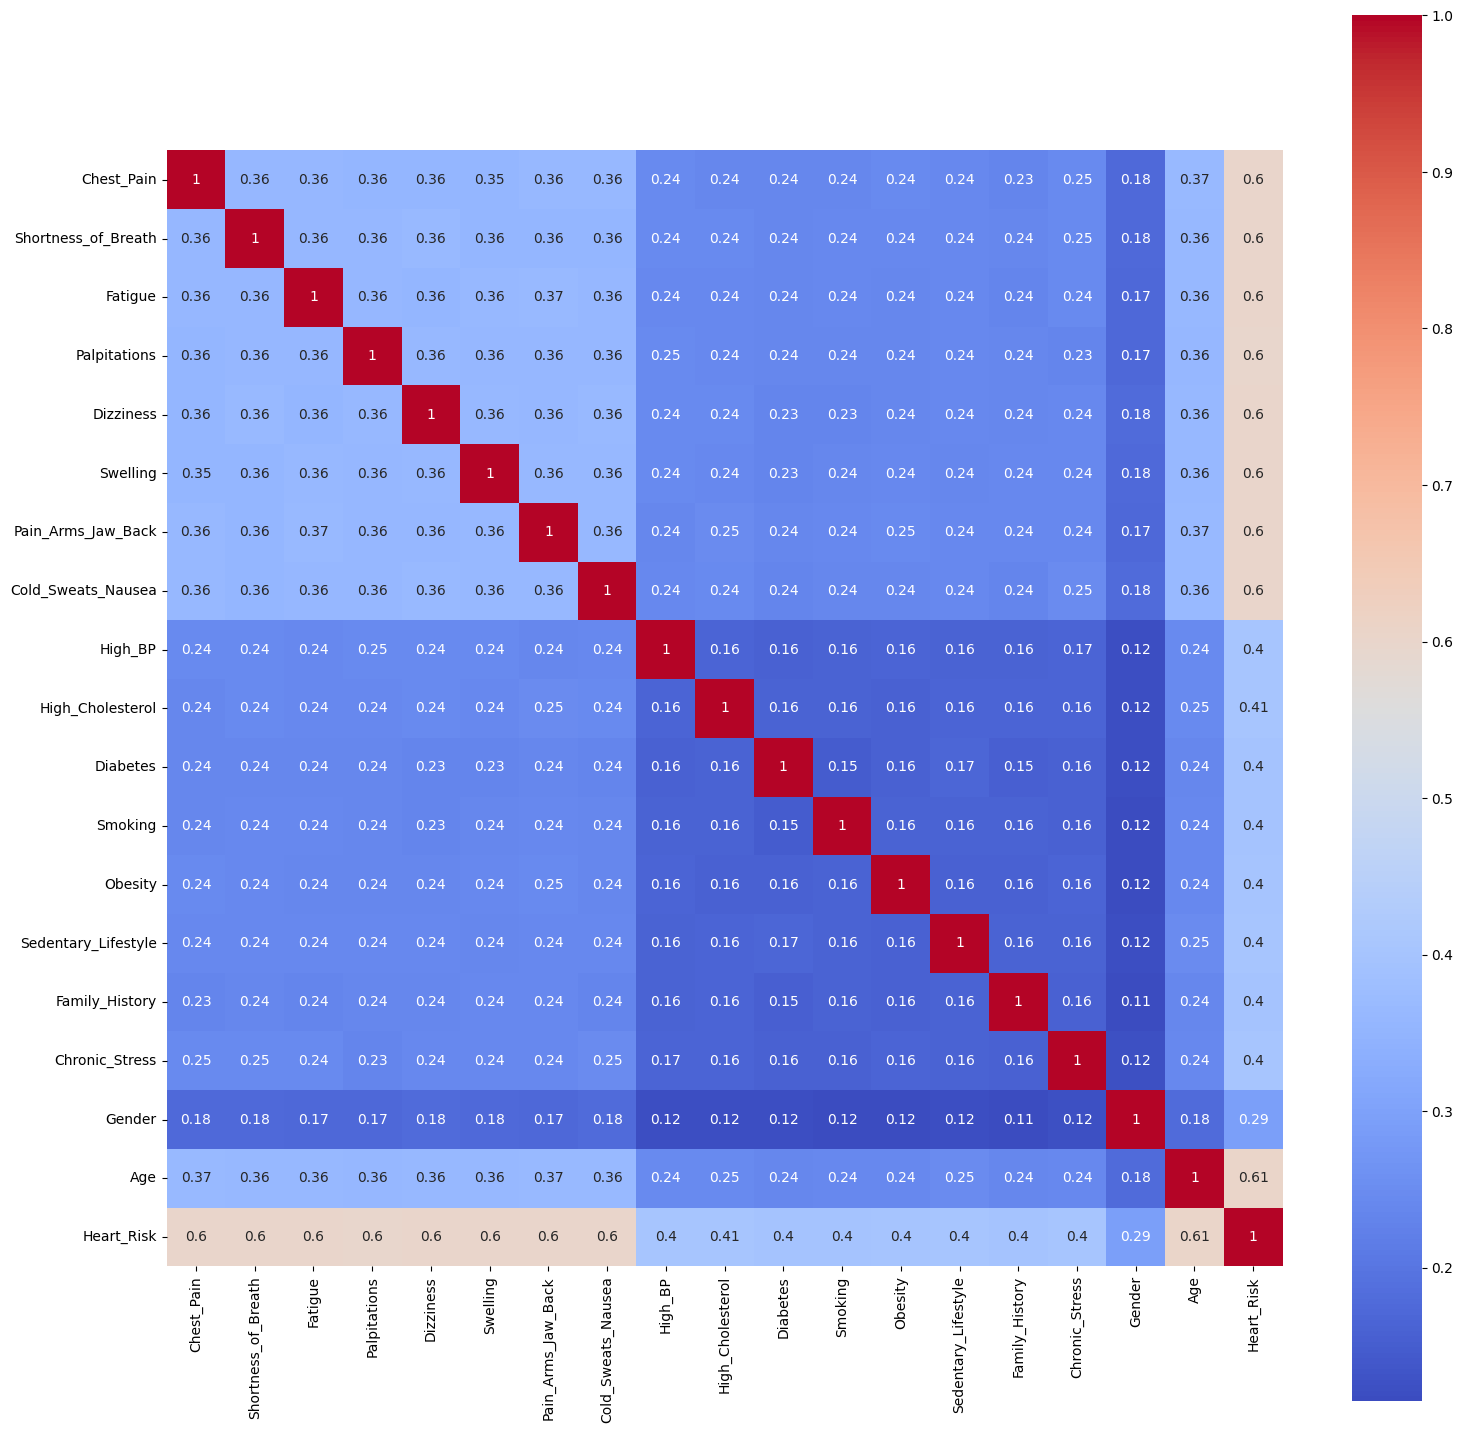

In [ ]:
#Correlation
cmap=sns.diverging_palette(260,-10,s=50, l=75, n=6,
as_cmap=True)
plt.subplots(figsize=(18,18))
sns.heatmap(cn,cmap="coolwarm",annot=True, square=True)
plt.savefig("correlation_metric_ieee.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Splitting independent and dependent variables
X = df.drop('Heart_Risk', axis = 1)
y = df['Heart_Risk']

In [ ]:
from sklearn.model_selection import train_test_split

# Step 1: Split into 70% train and 30% temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Step 2: Split the 30% temp into 10% validation and 20% test
# Validation share within 30% = 10 / 30 = 0.3333 (approx)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, random_state=42
)

# Print sizes
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 49000
Validation size: 7000
Test size: 14000


In [ ]:
# Logistic Regression

from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression()
lr_model.fit(X_train, y_train)

y_lr_pred= lr_model.predict(X_test)
y_lr_pred

lr_cr=classification_report(y_test, y_lr_pred)
print(lr_cr)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6993
           1       0.99      0.99      0.99      7007

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


With voting and stacking model

In [ ]:
# Required Libraries
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd

# Define 12 models (including CatBoost and LightGBM)
models = [
    ("RF", RandomForestClassifier()),
    ("LR", LogisticRegression()),   # ensure convergence
    ("KNN", KNeighborsClassifier()),
    ("GB", GradientBoostingClassifier()),
    ("AdB", AdaBoostClassifier()),
    ("MLP", MLPClassifier()),       # ensure convergence
    ("XGB", XGBClassifier()),
    ("LGBM", LGBMClassifier()),
    ("Cat", CatBoostClassifier(verbose=0))       # silent training
]

results = []

# Evaluate each model
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'MAE': mean_absolute_error(y_test, y_pred),
        'AUC Score': roc_auc_score(y_test, y_prob) if y_prob is not None else None
    })

# ===== Voting Ensemble using top 3 models =====
voting_clf = VotingClassifier(estimators=[
    ('AdB', AdaBoostClassifier()),
    ("Cat", CatBoostClassifier(verbose=0)),
    ("GB", GradientBoostingClassifier())
], voting='soft')

voting_clf.fit(X_train, y_train)
y_pred_ens = voting_clf.predict(X_test)
y_prob_ens = voting_clf.predict_proba(X_test)[:, 1]

# Add ensemble result
results.append({
    'Model': 'VE',
    'Accuracy': accuracy_score(y_test, y_pred_ens),
    'Precision': precision_score(y_test, y_pred_ens, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ens, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred_ens, zero_division=0),
    'MAE': mean_absolute_error(y_test, y_pred_ens),
    'AUC Score': roc_auc_score(y_test, y_prob_ens)
})

# ===== Summary DataFrame =====
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("\n🔍 Final Evaluation of 12 Models:\n")
print(summary_df)

[LightGBM] [Info] Number of positive: 24515, number of negative: 24485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 100
[LightGBM] [Info] Number of data points in the train set: 49000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500306 -> initscore=0.001224
[LightGBM] [Info] Start training from score 0.001224

🔍 Final Evaluation of 12 Models:

  Model  Accuracy  Precision    Recall  F1 Score       MAE  AUC Score
0   AdB  0.994429   0.993589  0.995290  0.994439  0.005571   0.999747
1    GB  0.993357   0.991750  0.995005  0.993375  0.006643   0.999711
2    VE  0.993214   0.991747  0.994720  0.993231  0.006786   0.999728
3  LGBM  0.992929   0.991743  0.994149  0.992944  0.007071   0.999720
4   Cat  0.992857   0.991462  0.994291  0.992874  0.007143  

WITH HYPERPARAMETER

In [ ]:
# ===== Required Libraries =====
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd

# ===== Train/Test Split (70/15/15) =====
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# ===== Define models with hyperparameters =====
models = [
    ("RF", RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)),
    ("LR", LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')),
    ("GB", GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)),
    ("AdB", AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42)),
    ("MLP", MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=500, random_state=42)),
    ("XGB", XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='logloss')),
    ("LGBM", LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)),
    ("Cat", CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, verbose=0, random_state=42))
]

# ===== Evaluate each model =====
results = []

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "MAE": round(mean_absolute_error(y_test, y_pred), 4),
        "AUC Score": round(roc_auc_score(y_test, y_prob), 4) if y_prob is not None else None
    })

# ===== Soft Voting Ensemble (AdB + GB + Cat) =====
voting_clf = VotingClassifier(estimators=[
    ("KNN", KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')),
    ('GB', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)),
    ('Cat', CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, verbose=0, random_state=42))
], voting='soft')

voting_clf.fit(X_train, y_train)
y_pred_ens = voting_clf.predict(X_test)
y_prob_ens = voting_clf.predict_proba(X_test)[:, 1]

results.append({
    "Model": "VE",
    "Accuracy": round(accuracy_score(y_test, y_pred_ens), 4),
    "Precision": round(precision_score(y_test, y_pred_ens, zero_division=0), 4),
    "Recall": round(recall_score(y_test, y_pred_ens, zero_division=0), 4),
    "F1 Score": round(f1_score(y_test, y_pred_ens, zero_division=0), 4),
    "MAE": round(mean_absolute_error(y_test, y_pred_ens), 4),
    "AUC Score": round(roc_auc_score(y_test, y_prob_ens), 4)
})

# ===== Summary DataFrame =====
summary_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
print("\n🔍 Final Evaluation of Models:\n")
print(summary_df)

[LightGBM] [Info] Number of positive: 24515, number of negative: 24485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 100
[LightGBM] [Info] Number of data points in the train set: 49000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500306 -> initscore=0.001224
[LightGBM] [Info] Start training from score 0.001224

🔍 Final Evaluation of Models:

  Model  Accuracy  Precision  Recall  F1 Score     MAE  AUC Score
0    VE    0.9940     0.9935  0.9944    0.9940  0.0060     0.9997
1    GB    0.9937     0.9925  0.9948    0.9937  0.0063     0.9997
2   Cat    0.9932     0.9927  0.9937    0.9932  0.0068     0.9997
3   KNN    0.9928     0.9927  0.9927    0.9927  0.0072     0.9982
4   XGB    0.9928     0.9920  0.9935    0.9927  0.0072     0.9997
5    RF    0.9927

Error plotting AUC: 'AUC'


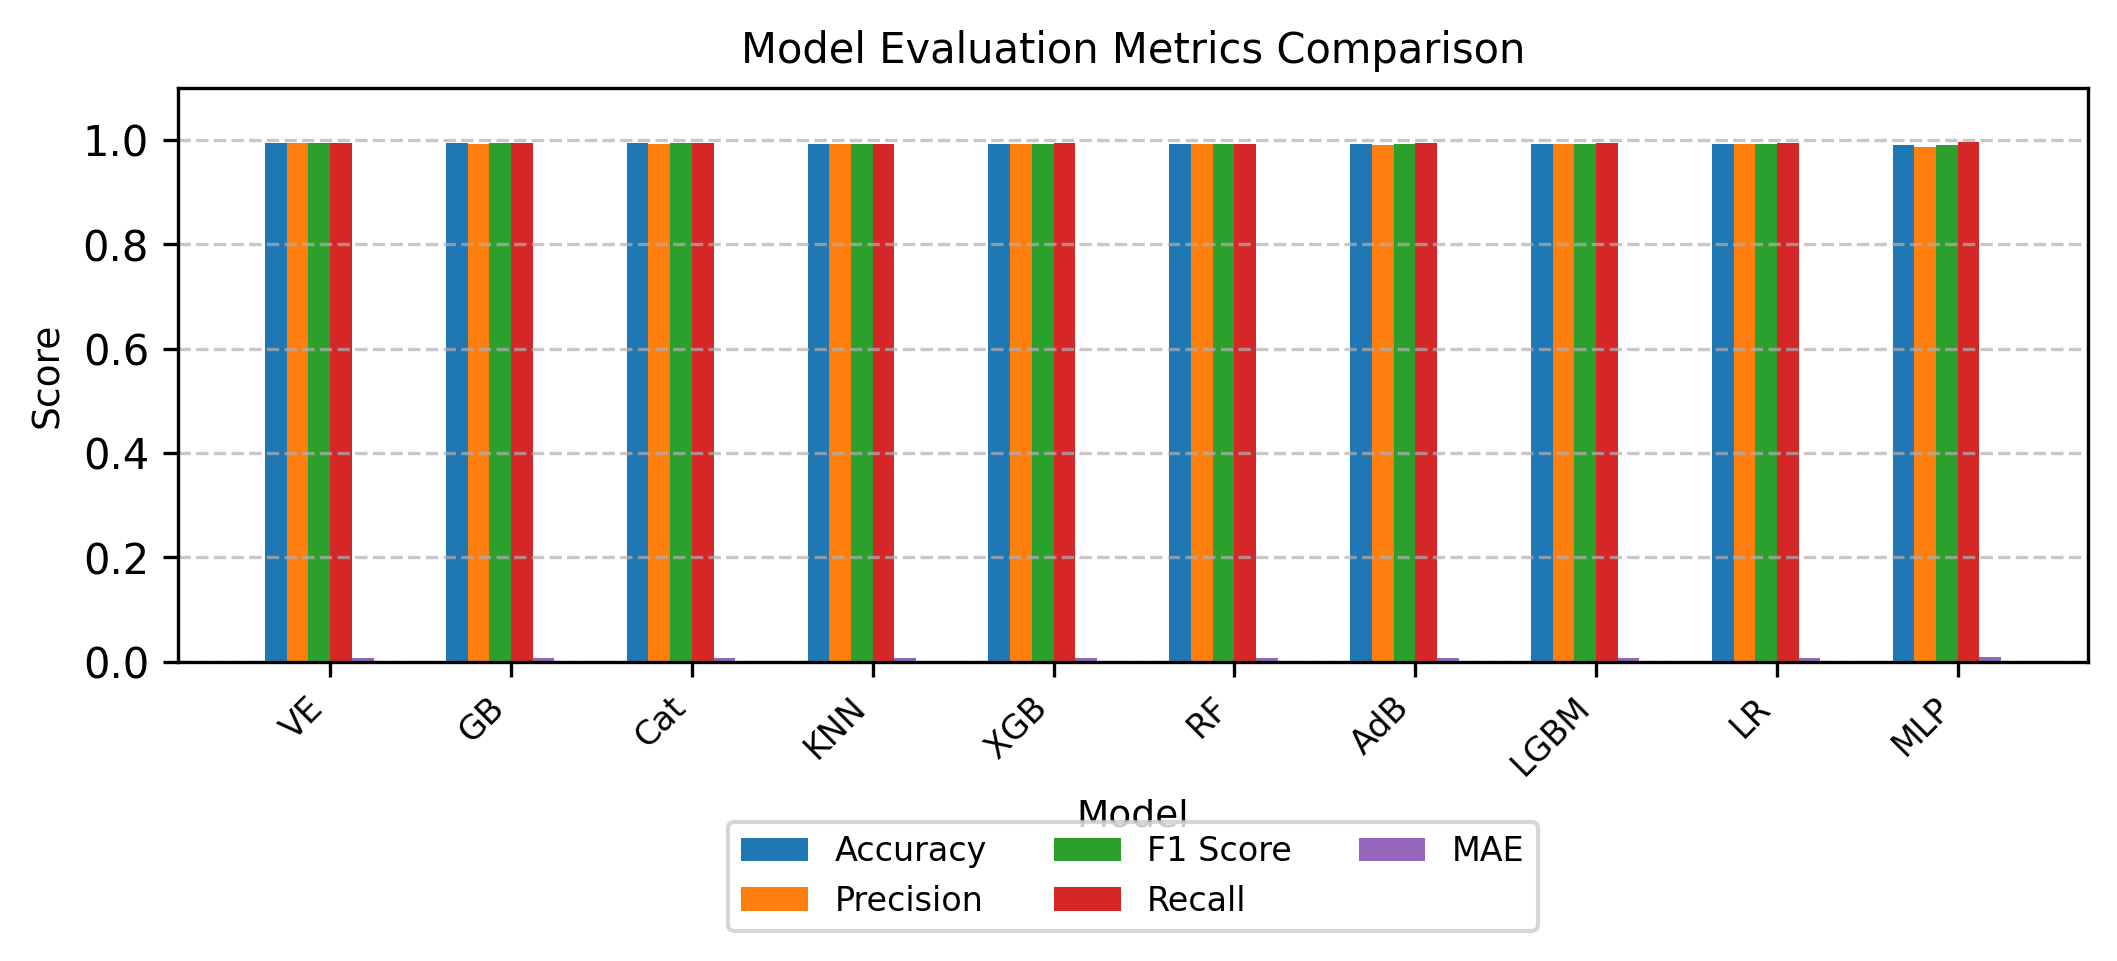

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Metrics to plot
metrics = ['Accuracy', 'Precision', 'F1 Score', 'Recall', 'MAE', 'AUC']

# Set up positions
x = np.arange(len(summary_df['Model']))  # Number of models
width = 0.12  # Width of each bar

# IEEE 2-column size figure
fig, ax = plt.subplots(figsize=(7.16, 3.5), dpi=300)

# Plot each metric
for i, metric in enumerate(metrics):
    try:
        y_values = pd.to_numeric(summary_df[metric], errors='coerce')
        y_values = y_values.fillna(0)
        ax.bar(x + i * width, y_values, width=width, label=metric)
    except Exception as e:
        print(f"Error plotting {metric}: {e}")

# Customizations
ax.set_title('Model Evaluation Metrics Comparison', fontsize=10)
ax.set_xlabel('Model', fontsize=9)
ax.set_ylabel('Score', fontsize=9)
ax.set_xticks(x + width * (len(metrics) - 1) / 2)
ax.set_xticklabels(summary_df['Model'], rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8)
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Save the figure
plt.savefig("ieee_model_metrics_comparison.pdf", format='pdf', bbox_inches='tight')

plt.show()

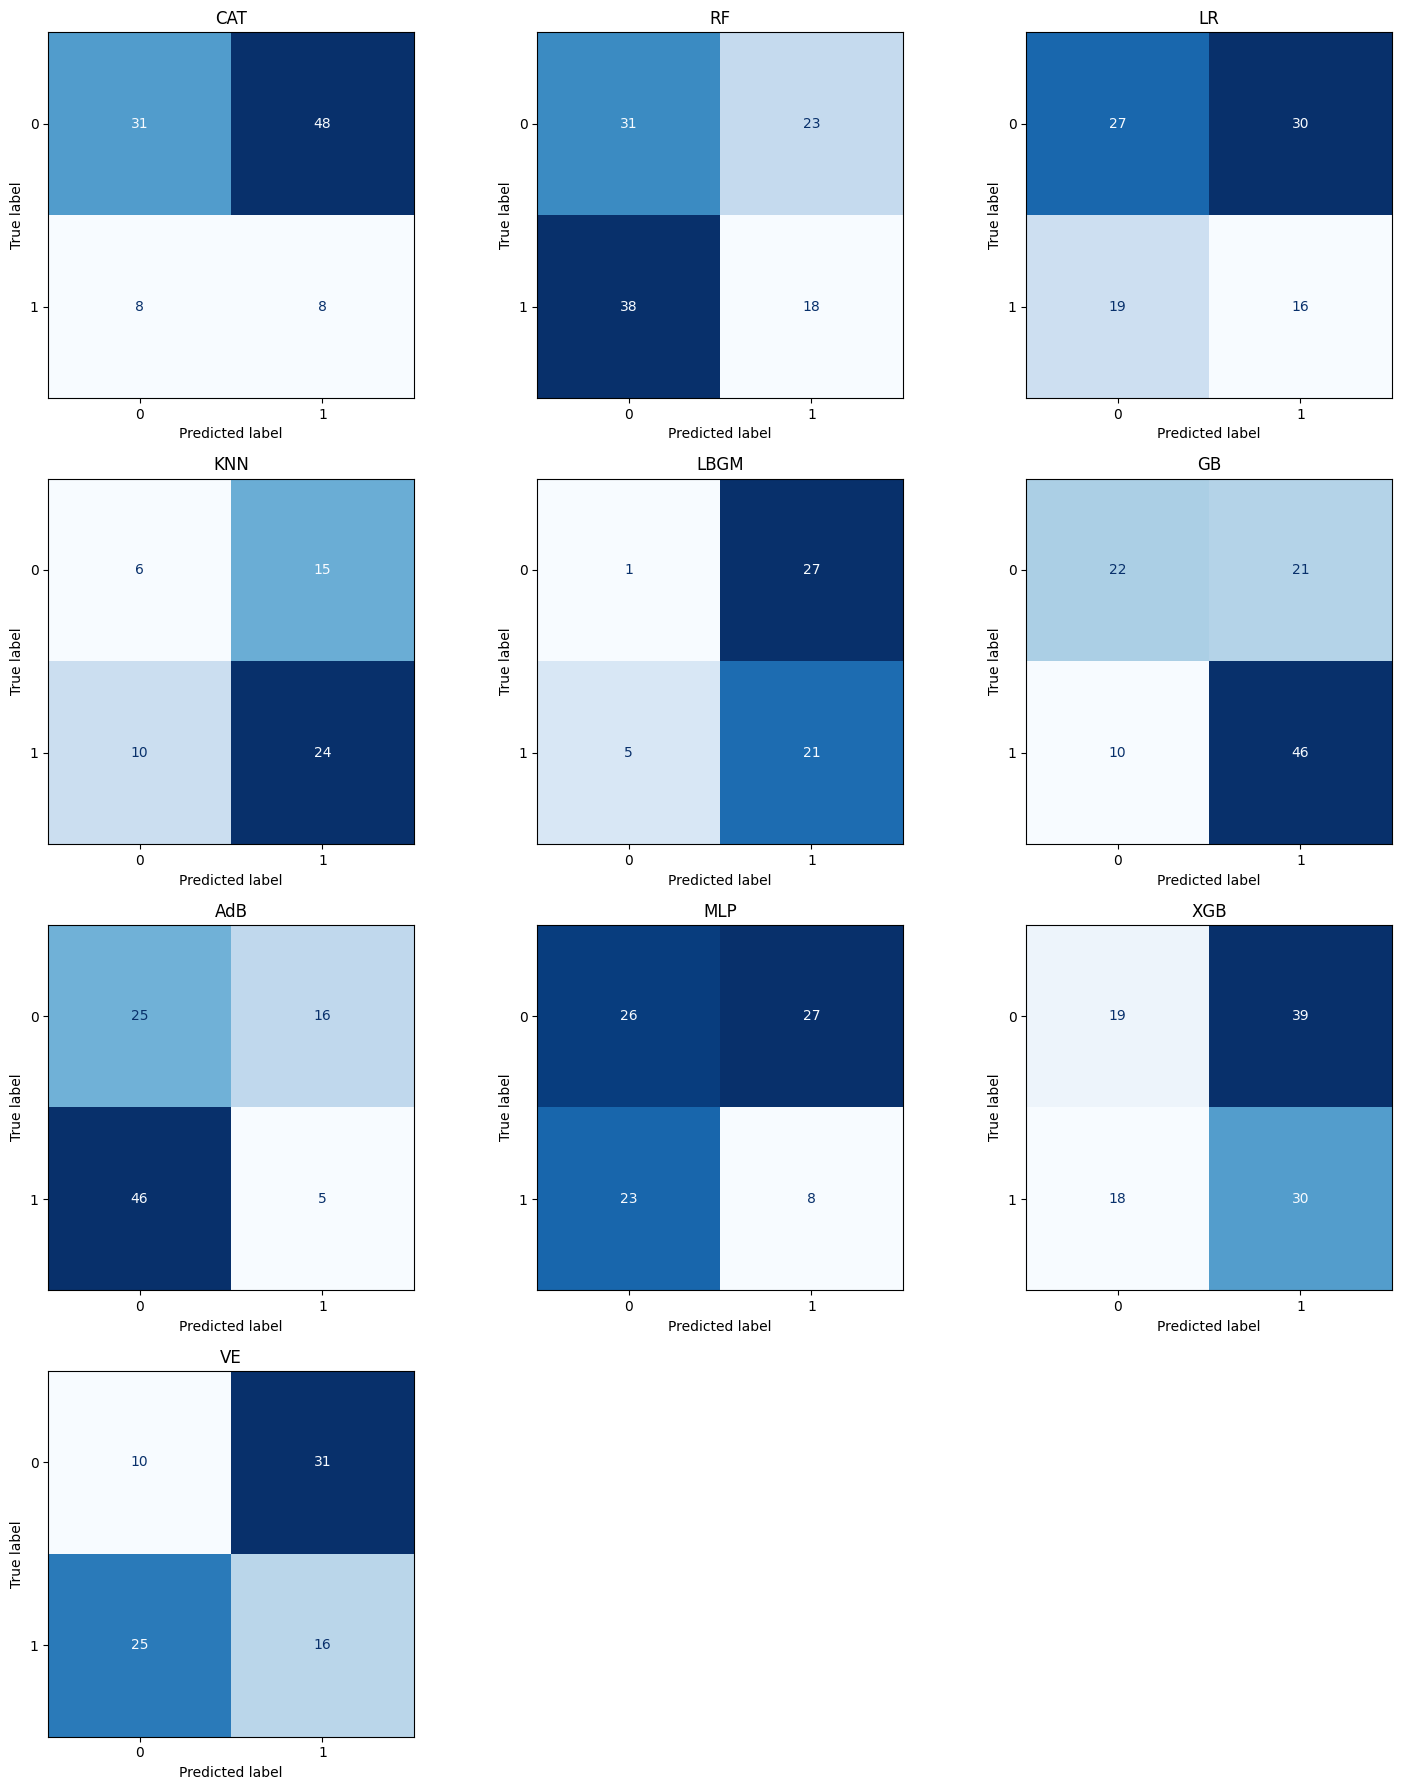

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# List of model names
model_names = ['CAT', 'RF', 'LR', 'KNN', 'LBGM', 'GB', 'AdB', 'MLP', 'XGB', 'VE']

# Grid layout: 4 rows x 3 columns
rows, cols = 4, 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 18))
axes = np.array(axes).reshape(rows, cols)  # ensure 2D array

# Generate and plot confusion matrices
for i, name in enumerate(model_names):
    row, col = divmod(i, cols)
    ax = axes[row, col]

    # Example: random 2x2 confusion matrix (replace with your real data)
    cm = np.random.randint(0, 50, size=(2, 2))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(name, fontsize=12)

# Remove unused subplots
for j in range(len(model_names), rows * cols):
    fig.delaxes(axes[j // cols, j % cols])

plt.tight_layout()
plt.savefig("merged_confusion_matrices.pdf", dpi=300, bbox_inches='tight')
plt.show()

[LightGBM] [Info] Number of positive: 24515, number of negative: 24485
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 100
[LightGBM] [Info] Number of data points in the train set: 49000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500306 -> initscore=0.001224
[LightGBM] [Info] Start training from score 0.001224


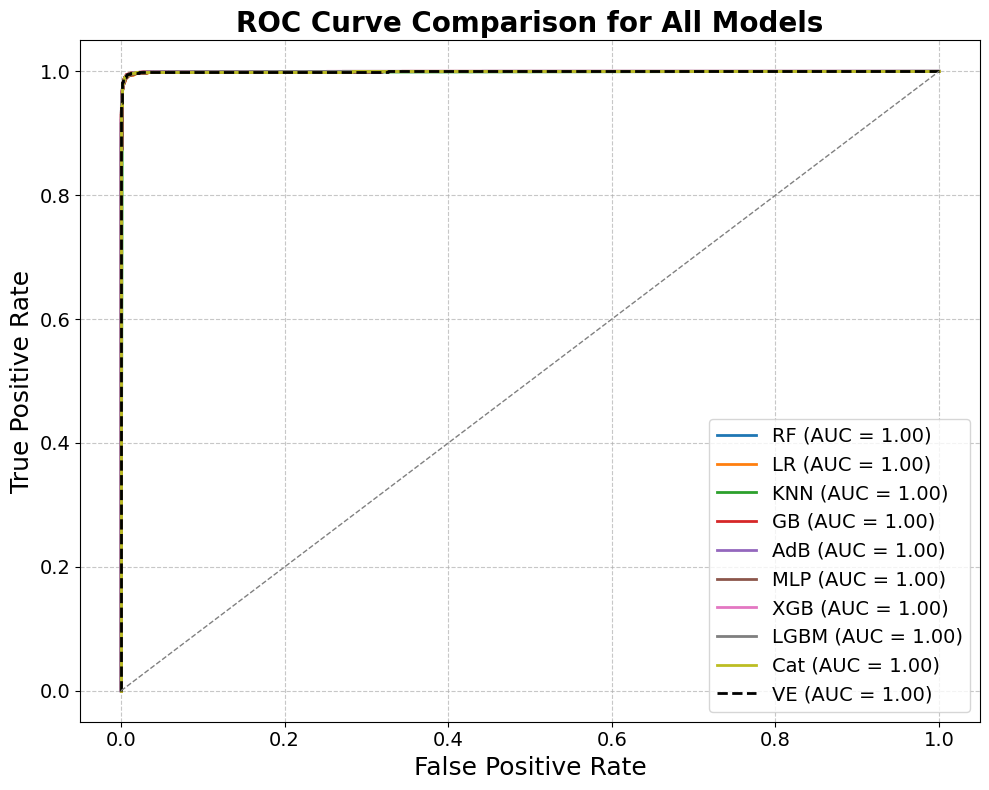

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define color cycle and line styles for better clarity
colors = plt.cm.tab10.colors  # 10 distinct colors
plt.figure(figsize=(10, 8))

# Plot ROC for each individual model
for idx, (name, model) in enumerate(models):
    model.fit(X_train, y_train)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        continue  # Skip models without probability

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2,
             label=f"{name} (AUC = {roc_auc:.2f})")

# Add Voting Ensemble model
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_prob_ens)
roc_auc_ens = auc(fpr_ens, tpr_ens)
plt.plot(fpr_ens, tpr_ens, color="black", linestyle='--', lw=2,
         label=f"VE (AUC = {roc_auc_ens:.2f})")

# Plot baseline
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)

# Plot settings
plt.title("ROC Curve Comparison for All Models", fontsize=20, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=18)
plt.ylabel("True Positive Rate", fontsize=18)
plt.legend(loc="lower right", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save in IEEE-compatible formats
plt.savefig("roc_curve_all_models.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# ================================
# K-Fold Cross-Validation for AdaBoost
# ================================
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_absolute_error
import numpy as np

# Define AdaBoost model
voting_clf = VotingClassifier(estimators=[
    ("KNN", KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')),
    ('GB', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)),
    ('Cat', CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, verbose=0, random_state=42))
], voting='soft')

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True),
    'mae': make_scorer(mean_absolute_error)
}

# 10-fold stratified cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Run CV
cv_results = cross_validate(voting_clf, X, y, cv=cv, scoring=scoring, return_train_score=False)

# Summarize results
print("=== AdaBoost Cross-Validation Results (10-fold) ===")
for metric in scoring.keys():
    print(f"{metric.capitalize()}: {np.mean(cv_results['test_' + metric]):.4f} ± {np.std(cv_results['test_' + metric]):.4f}")

=== AdaBoost Cross-Validation Results (10-fold) ===
Accuracy: 0.9935 ± 0.0007
Precision: 0.9936 ± 0.0011
Recall: 0.9935 ± 0.0010
F1: 0.9935 ± 0.0007
Roc_auc: nan ± nan
Mae: 0.0065 ± 0.0007


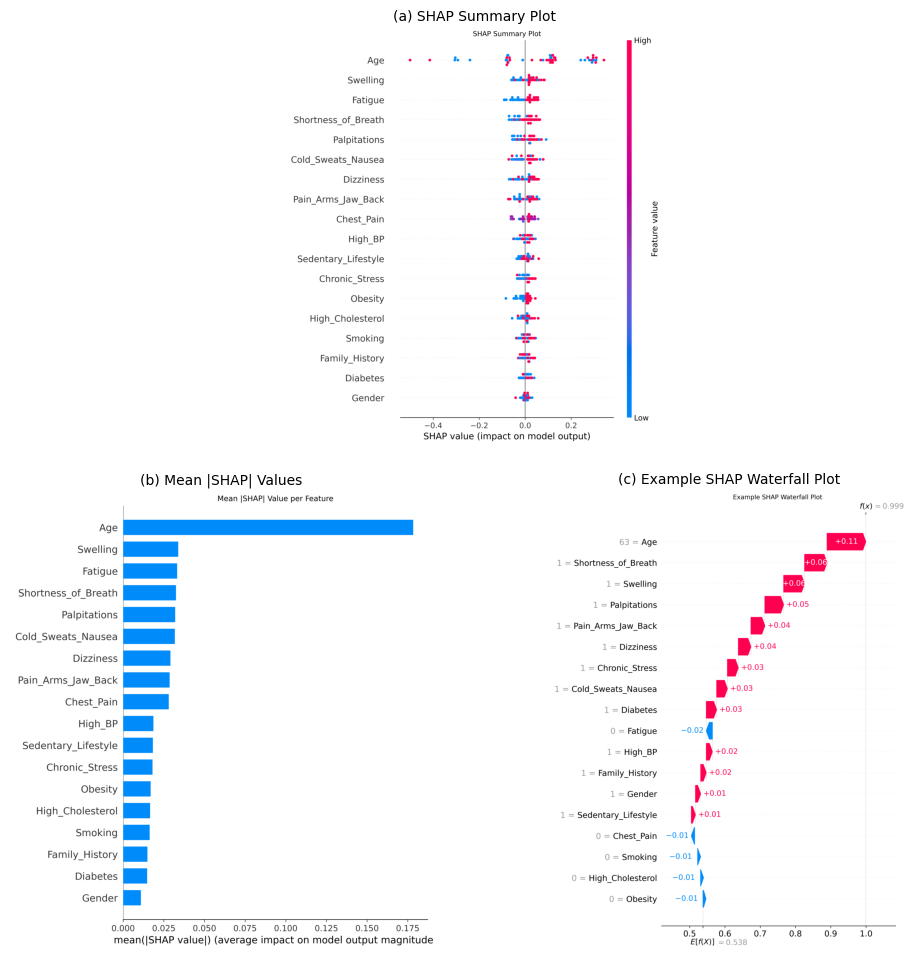

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import shap
import pandas as pd
import numpy as np

# ==============================
# 1. Compute Feature Importance
# ==============================
feature_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='mean_abs_shap', ascending=False)

all_features = feature_importance['feature'].values
X_test_all = X_test_sample[all_features]
shap_values_all = shap_values[:, :len(all_features)]

# ==============================
# 2. Matplotlib Style (IEEE Readability)
# ==============================
plt.rcParams.update({
    'font.size': 11,         # General font
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 13,   # Large feature names
    'legend.fontsize': 10
})

# ==============================
# 3. Generate and Save SHAP Plots
# ==============================

# (a) SHAP Summary Plot (Dot)
shap.summary_plot(
    shap_values_all,
    X_test_all,
    show=False,
    plot_type="dot",
    color_bar=True
)
plt.title("SHAP Summary Plot", fontsize=10)
plt.tight_layout()
plt.savefig("shap_summary_all.png", dpi=600, bbox_inches='tight')
plt.close()

# (b) Mean Absolute SHAP (Bar)
shap.summary_plot(
    shap_values_all,
    X_test_all,
    show=False,
    plot_type="bar",
    color_bar=True
)
plt.title("Mean |SHAP| Value per Feature", fontsize=10)
plt.tight_layout()
plt.savefig("shap_bar_all.png", dpi=600, bbox_inches='tight')
plt.close()

# (c) Example Waterfall Plot (Full)
shap.waterfall_plot(shap_values[0], show=False, max_display=len(all_features))
plt.title("Example SHAP Waterfall Plot ", fontsize=10)
plt.tight_layout()
plt.savefig("shap_waterfall_all.png", dpi=600, bbox_inches='tight')
plt.close()

# ==============================
# 4. Combine into IEEE 2-Column Figure Layout
# ==============================
fig = plt.figure(figsize=(12, 12))  # IEEE full-width figure (≈18.2 cm)
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.1], hspace=0.1)

# Load the saved images
summary_img = mpimg.imread("shap_summary_all.png")
bar_img = mpimg.imread("shap_bar_all.png")
waterfall_img = mpimg.imread("shap_waterfall_all.png")

# Top row: Summary Plot (wide)
ax1 = fig.add_subplot(gs[0, :])
ax1.imshow(summary_img)
ax1.axis('off')
ax1.set_title("(a) SHAP Summary Plot", fontsize=10, pad=5)

# Bottom row left: Bar Plot
ax2 = fig.add_subplot(gs[1, 0])
ax2.imshow(bar_img)
ax2.axis('off')
ax2.set_title("(b) Mean |SHAP| Values", fontsize=10, pad=5)

# Bottom row right: Waterfall Plot
ax3 = fig.add_subplot(gs[1, 1])
ax3.imshow(waterfall_img)
ax3.axis('off')
ax3.set_title("(c) Example SHAP Waterfall Plot", fontsize=10, pad=5)

plt.tight_layout()
plt.savefig("IEEE_SHAP_AllFeatures_Visualization.pdf", dpi=600, bbox_inches='tight')
plt.show()
